<a href="https://colab.research.google.com/github/sagasucksatlife1/QuantProjects/blob/main/Hierarchical_Risk_Parity_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HIERARCHAIL RISK PARITY

The HRP is a fairly mordern concept introduced in 2016, why do we need it? Well simply because markowitz theory accorinding to our experimentations though these projects we have seen markowitz theory is hypocritical says diversify proftolfio but when i actaully do that it is the most concertrated portfolio and a little change in return leads to the most flipped portfolio genertaion out of all, so not reliable. and also inverses the covariance martix.

Now we come down to risk parity, i love it but the thing is it completly ignores the possiblity of possible correlation between the companies leading to equal risk distribution but a possible clustered portfolio depending on us to do the diversification ourselves.

Now comes the HRP, what this does is forms clusters of the given companies, so every company in the cluster move exactly the same, they we divide the allocation in btw clusters based on how those custers react to different market changes, the variance of these clusters, providng allocation inversly to the level of risk.

In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

tickers = [
    "RELIANCE.NS", "HDFCBANK.NS","ICICIBANK.NS","SBIN.NS", "BHARTIARTL.NS","INFY.NS","TCS.NS", "LT.NS", "HINDUNILVR.NS", "ITC.NS","BAJFINANCE.NS",
    "AXISBANK.NS","KOTAKBANK.NS","ASIANPAINT.NS", "MARUTI.NS", "M&M.NS","SUNPHARMA.NS", "NTPC.NS","POWERGRID.NS", "ULTRACEMCO.NS"
]

data = yf.download(tickers, start= "2020-05-20", end="2026-05-26", interval= "1D")
data = data["Close"]

returns = data.pct_change()
returns = returns.dropna()
returns.columns = returns.columns.str.replace('INF', 'INFY', regex=False)
returns.tail()

/tmp/ipykernel_1520/2254575160.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start= "2020-05-20", end="2026-05-26", interval= "1D")
[*********************100%***********************]  20 of 20 completed


Ticker,ASIANPAINT.NS,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFYY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,M&M.NS,MARUTI.NS,NTPC.NS,POWERGRID.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,ULTRACEMCO.NS
Date,,,,,,,,,,,,,,,,,,,,
2026-05-19,-0.005088,0.000323,0.002660,-0.012693,-0.008066,-0.009449,-0.008233,0.047615,0.000484,-0.025140,0.000817,0.002789,-0.004610,0.002833,0.006913,-0.009881,0.010006,-0.012331,0.019228,-0.016694
2026-05-20,-0.000807,0.009287,-0.000487,-0.004494,-0.003869,-0.010569,-0.002821,-0.002674,-0.008862,0.003273,-0.002627,0.009669,0.003628,0.007833,0.004354,0.027973,0.002213,-0.001063,0.000129,0.003607
2026-05-21,0.000077,0.002800,-0.016737,-0.010289,-0.000461,-0.013715,0.004445,-0.010472,0.001626,-0.006133,0.004552,-0.007431,0.000538,-0.009301,-0.001167,-0.007428,0.000000,0.005850,-0.000086,0.005697
2026-05-22,0.015777,0.025612,0.009806,-0.007373,0.010077,0.011290,0.017300,-0.005672,-0.020613,0.008665,0.009279,-0.005712,-0.001768,-0.000386,-0.017526,0.003631,-0.001788,-0.024692,-0.004254,0.008280
2026-05-25,0.006819,0.020072,0.027658,0.001817,0.026148,-0.003222,0.021751,-0.005108,0.007458,0.022647,0.027199,0.018726,0.014091,0.003602,0.003568,0.009229,0.021492,-0.002168,0.009579,0.013571


We download the data of 20 nifty companies over the past 6 years, then we convert that data into returns because the returns are stationary in nature and its always better to have stationary objects.

In [2]:
covariance_matrix = returns.cov()
correlation_matrix = returns.corr()
correlation_matrix.head()

Ticker,ASIANPAINT.NS,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFYY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,M&M.NS,MARUTI.NS,NTPC.NS,POWERGRID.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,ULTRACEMCO.NS
Ticker,,,,,,,,,,,,,,,,,,,,
ASIANPAINT.NS,1.000000,0.170348,0.303556,0.172838,0.243938,0.360454,0.220567,0.183130,0.203792,0.228620,0.276942,0.241824,0.332036,0.156275,0.130453,0.256283,0.189919,0.178520,0.219439,0.353536
AXISBANK.NS,0.170348,1.000000,0.460994,0.279063,0.470628,0.175328,0.651466,0.194216,0.251945,0.429953,0.410427,0.318082,0.307280,0.305024,0.243063,0.304572,0.569937,0.144194,0.167606,0.340621
BAJFINANCE.NS,0.303556,0.460994,1.000000,0.294322,0.467450,0.209631,0.488730,0.225370,0.258177,0.461598,0.388445,0.381538,0.342342,0.271951,0.196666,0.341043,0.481837,0.183448,0.210946,0.371886
BHARTIARTL.NS,0.172838,0.279063,0.294322,1.000000,0.269470,0.149883,0.328083,0.210120,0.227070,0.265092,0.279528,0.288219,0.273704,0.242788,0.220163,0.257609,0.297455,0.263548,0.214974,0.255924
HDFCBANK.NS,0.243938,0.470628,0.467450,0.269470,1.000000,0.190653,0.564942,0.233585,0.227139,0.514691,0.427353,0.355822,0.305335,0.239100,0.219339,0.345889,0.455410,0.156373,0.213460,0.384133


in this step we convert the returns and take out their covarinace and correlation matrix.

In [9]:
distance_matrix = np.zeros(correlation_matrix.shape)
for i in range(len(correlation_matrix.columns)):
  for j in range(len(correlation_matrix.columns)):
    distance_matrix[i, j] = np.sqrt(0.5 * (1 - correlation_matrix.iloc[i, j]))



Before we start merging clusters, we need to compute the distance matrix so we can join merge clusters, so that highly correlated pairs with the shortest distance.This satisfies the mathematical properties of a proper metric (non-negativity, symmetry, triangle inequality). Assets that move together → ρ close to 1 → distance near 0. Uncorrelated → distance near 0.7. Inverse → distance near 1.


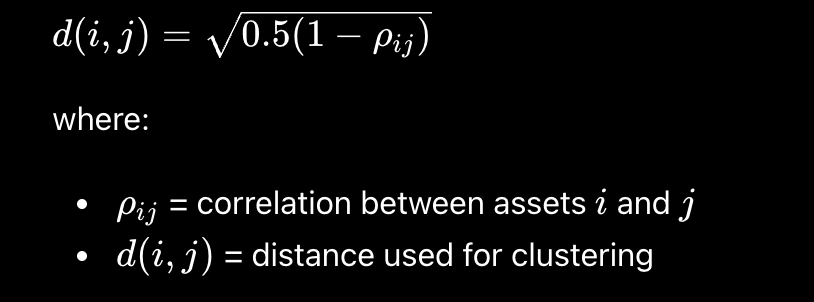

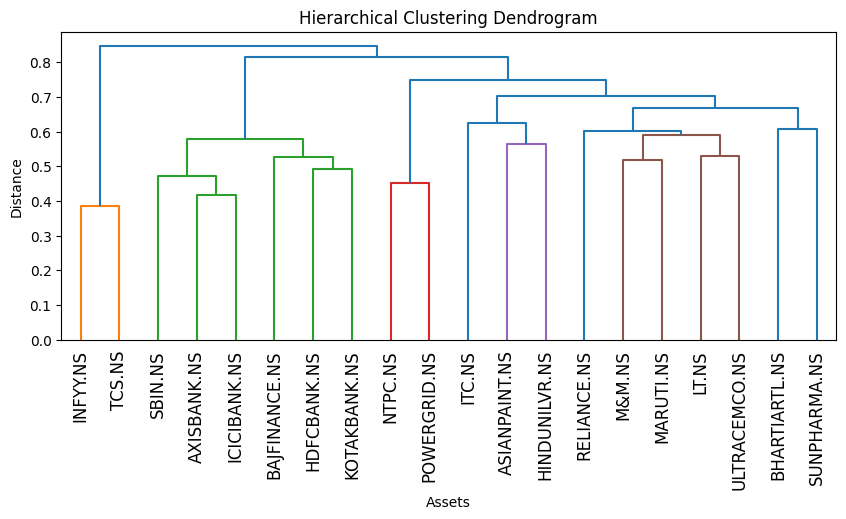

In [11]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

condensed_distance = squareform(distance_matrix)
linkage_matrix = linkage(condensed_distance, method='ward')

plt.figure(figsize=(10,4))

dendrogram(linkage_matrix, labels=correlation_matrix.columns, leaf_rotation= 90)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Assets")
plt.ylabel("Distance")

plt.show()


we run hierarchical agglomerative clustering on the distance matrix using SciPy's linkage. This builds a dendrogram — a tree showing which assets merged first (most similar), which merged later (less similar). The choice of linkage method matters: single linkage tends to chain, complete linkage is more conservative, Ward minimizes within-cluster variance and produces the most compact clusters. The output is a tree, not flat clusters. In our case we used the wards method to link the cluster together.

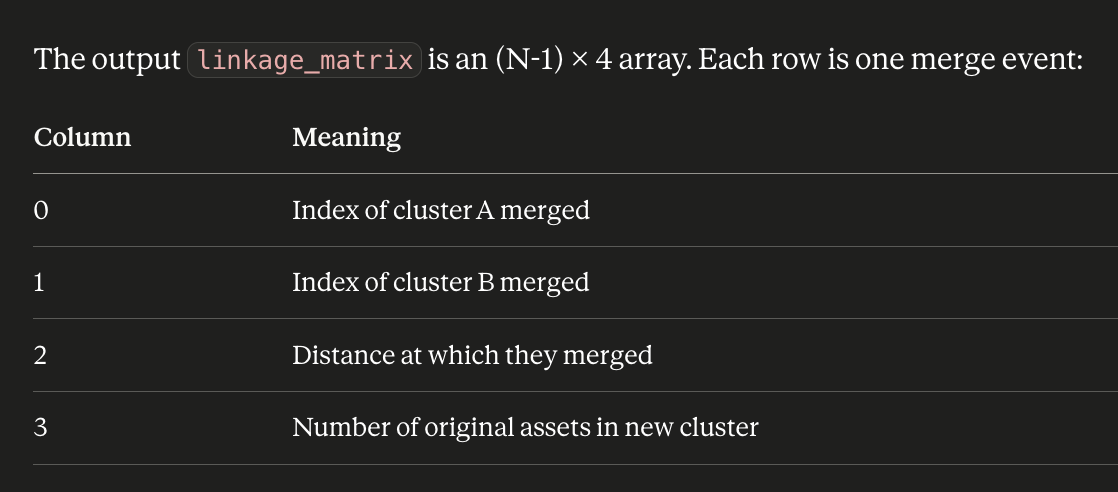

In [5]:
sorted_index = dendrogram(linkage_matrix, no_plot=True)['leaves']
quasi_diagonalised_cov = covariance_matrix.iloc[sorted_index, sorted_index]

print(quasi_diagonalised_cov)

Ticker         INFYY.NS    TCS.NS   SBIN.NS  AXISBANK.NS  ICICIBANK.NS  \
Ticker                                                                   
INFYY.NS       0.000255  0.000155  0.000046     0.000055      0.000056   
TCS.NS         0.000155  0.000192  0.000041     0.000041      0.000038   
SBIN.NS        0.000046  0.000041  0.000313     0.000179      0.000162   
AXISBANK.NS    0.000055  0.000041  0.000179     0.000316      0.000179   
ICICIBANK.NS   0.000056  0.000038  0.000162     0.000179      0.000240   
BAJFINANCE.NS  0.000072  0.000058  0.000170     0.000163      0.000151   
HDFCBANK.NS    0.000053  0.000042  0.000115     0.000120      0.000125   
KOTAKBANK.NS   0.000043  0.000034  0.000114     0.000120      0.000117   
NTPC.NS        0.000031  0.000025  0.000126     0.000090      0.000073   
POWERGRID.NS   0.000028  0.000026  0.000098     0.000072      0.000065   
ITC.NS         0.000029  0.000029  0.000077     0.000060      0.000056   
ASIANPAINT.NS  0.000044  0.000046  0.0

We reorder the rows/columns of the covariance matrix so that similar assets are adjacent, this produces a "quasi-diagonal" structure where the large blocks along the diagonal correspond to clusters, so when we reorder these clusters into and we split them more we dont end up slpit single clusters and clusters stick together.

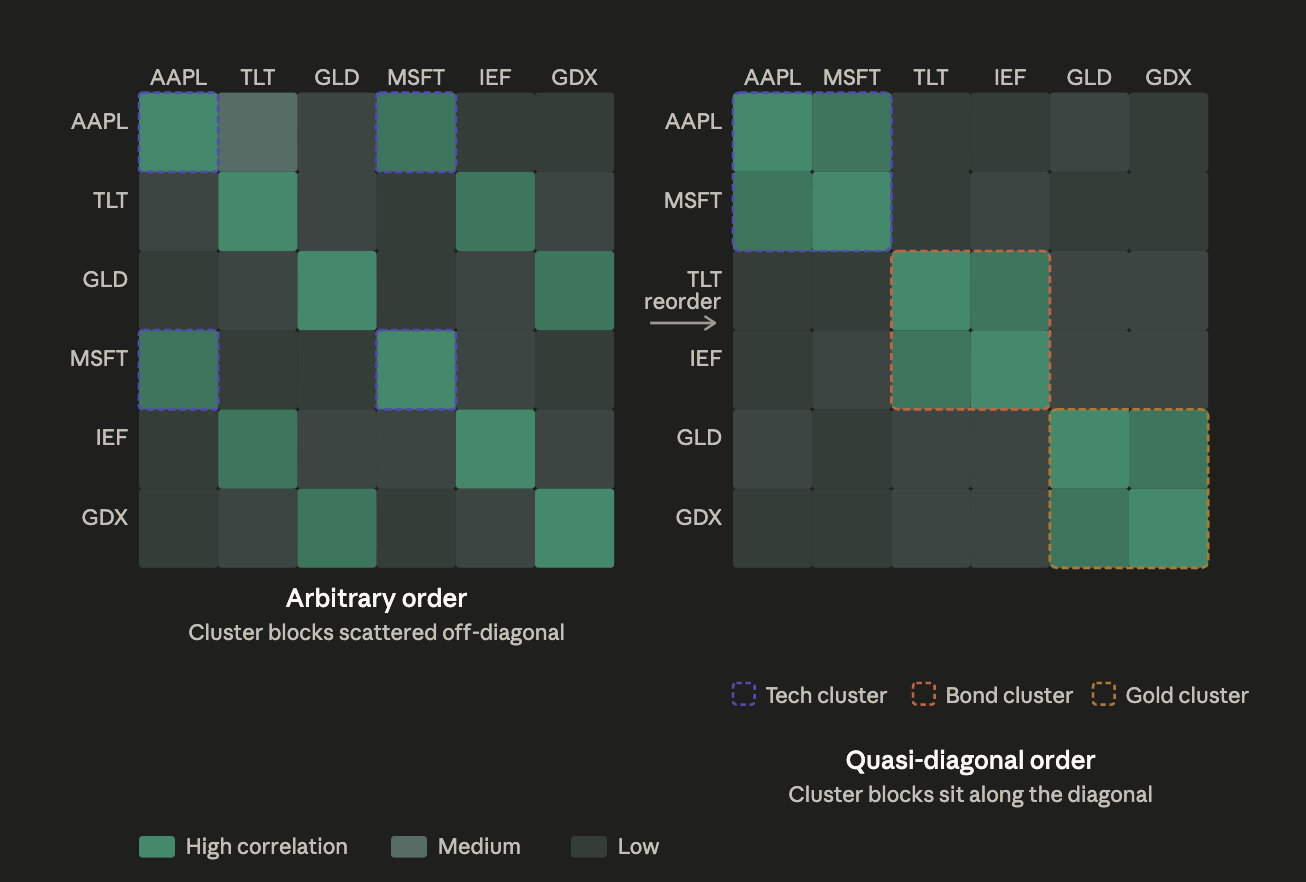

In [6]:
weights = pd.Series(1.0, index=quasi_diagonalised_cov.index)
cluster_queue = [quasi_diagonalised_cov.index.tolist()]

while len(cluster_queue) > 0:
  current_cluster_names = cluster_queue.pop(0)
  if len(current_cluster_names) <= 1:
    continue
  split_point = len(current_cluster_names) // 2
  cluster_1_names = current_cluster_names[:split_point]
  cluster_2_names = current_cluster_names[split_point:]
  cov_1 = quasi_diagonalised_cov.loc[cluster_1_names, cluster_1_names]
  cov_2 = quasi_diagonalised_cov.loc[cluster_2_names, cluster_2_names]

  w_1 = np.repeat(1/len(cluster_1_names), len(cluster_1_names))
  w_2 = np.repeat(1/len(cluster_2_names), len(cluster_2_names))

  var_1 = np.dot(np.dot(w_1.T, cov_1), w_1)
  var_2 = np.dot(np.dot(w_2.T, cov_2), w_2)

  alpha = 1 - var_1 / (var_1 + var_2)

  weights.loc[cluster_1_names] *= alpha
  weights.loc[cluster_2_names] *= (1 - alpha)
  cluster_queue.append(cluster_1_names)
  cluster_queue.append(cluster_2_names)

print(weights)

Ticker
INFYY.NS         0.048902
TCS.NS           0.065024
SBIN.NS          0.042844
AXISBANK.NS      0.025344
ICICIBANK.NS     0.033365
BAJFINANCE.NS    0.029685
HDFCBANK.NS      0.057609
KOTAKBANK.NS     0.058264
NTPC.NS          0.032169
POWERGRID.NS     0.032211
ITC.NS           0.082748
ASIANPAINT.NS    0.066605
HINDUNILVR.NS    0.081360
RELIANCE.NS      0.041554
M&M.NS           0.026867
MARUTI.NS        0.057936
LT.NS            0.052170
ULTRACEMCO.NS    0.061156
BHARTIARTL.NS    0.048312
SUNPHARMA.NS     0.055875
dtype: float64


Now we split the list in half, measure which half is riskier, and allocate capital inversely. Then repeat on each half. It's a binary tree traversal that multiplies weights down from the root.

The key insight: weights are multiplicative. we start at 1.0 for every asset, then at each split we scale the entire left cluster by alpha and the right cluster by 1 - alpha. By the time we've bisected all the way down to individual assets, each weight is a product of all the alpha decisions made at every level above it.

In [18]:
portfolio_returns = (returns * weights).sum(axis=1)

total_return     = (1 + portfolio_returns).prod() - 1
ann_return       = (1 + total_return) ** (252 / len(portfolio_returns)) - 1
ann_vol          = portfolio_returns.std() * np.sqrt(252)
sharpe           = ann_return / ann_vol
max_dd           = ((1 + portfolio_returns).cumprod() / (1 + portfolio_returns).cumprod().cummax() - 1).min()


print(f"Total Return:        {total_return:.2%}")
print(f"Annualised Return:   {ann_return:.2%}")
print(f"Annualised Vol:      {ann_vol:.2%}")
print(f"Sharpe Ratio:        {sharpe:.2f}")
print(f"Max Drawdown:        {max_dd:.2%}")

Total Return:        211.91%
Annualised Return:   21.21%
Annualised Vol:      13.53%
Sharpe Ratio:        1.57
Max Drawdown:        -15.89%


HRP portfolio at 21.21% annualized. That's meaningful alpha for a purely systematic, no-forecast model.

Sharpe of 1.57 is excellent. Anything above 1.0 is considered good, above 1.5 is institutional-quality. achieving this with zero return forecasting — purely structural risk allocation.

Max drawdown of -15.89% is the standout number. Nifty 50 drew down ~38% in the Covid crash (Feb-Mar 2020). portfolio likely did better because HRP's cluster-aware allocation naturally underweights correlated assets during stress.

Vol at 13.53% annualized on an all-equity Indian portfolio is low.

                          HRP       EW
Total Return          211.91%  254.71%
Ann. Return            21.21%   23.88%
Ann. Vol               13.53%   14.25%
Sharpe                   1.57     1.68
Max Drawdown          -15.89%  -15.31%


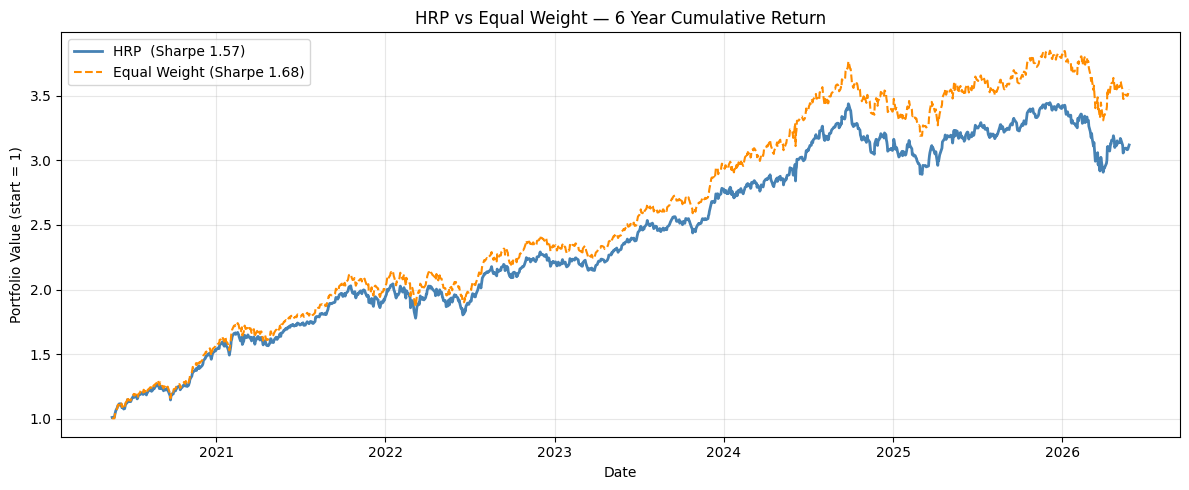

In [20]:
n = len(returns.columns)
ew_weights = pd.Series(1/n, index=returns.columns)
ew_returns = (returns * ew_weights).sum(axis=1)

# ── metrics ────────────────────────────────────────────────────────
ew_total  = (1 + ew_returns).prod() - 1
ew_ann    = (1 + ew_total) ** (252 / len(ew_returns)) - 1
ew_vol    = ew_returns.std() * np.sqrt(252)
ew_sharpe = ew_ann / ew_vol
ew_dd     = ((1 + ew_returns).cumprod() / (1 + ew_returns).cumprod().cummax() - 1).min()

print("=" * 40)
print(f"{'':20} {'HRP':>8} {'EW':>8}")
print("=" * 40)
print(f"{'Total Return':20} {total_return:>8.2%} {ew_total:>8.2%}")
print(f"{'Ann. Return':20} {ann_return:>8.2%} {ew_ann:>8.2%}")
print(f"{'Ann. Vol':20} {ann_vol:>8.2%} {ew_vol:>8.2%}")
print(f"{'Sharpe':20} {sharpe:>8.2f} {ew_sharpe:>8.2f}")
print(f"{'Max Drawdown':20} {max_dd:>8.2%} {ew_dd:>8.2%}")
print("=" * 40)

# ── plot ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

cum_hrp = (1 + portfolio_returns).cumprod()
cum_ew  = (1 + ew_returns).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(cum_hrp, color='steelblue',  linewidth=2,   label=f'HRP  (Sharpe {sharpe:.2f})')
plt.plot(cum_ew,  color='darkorange', linewidth=1.5,
         linestyle='--', label=f'Equal Weight (Sharpe {ew_sharpe:.2f})')
plt.title('HRP vs Equal Weight — 6 Year Cumulative Return')
plt.ylabel('Portfolio Value (start = 1)')
plt.xlabel('Date')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

HRP underperformed equal weight on a homogeneous large-cap equity universe during a sustained bull market, consistent with theoretical expectations.😢 HRP's advantage materializes in multi-asset portfolios with genuine cluster diversity and during drawdown periods. The max drawdown difference (-15.89% vs -15.31%) was marginal, suggesting limited tail-risk benefit when all assets share the same systemic risk factor🙂.

